In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\DR ALI\Downloads\student_data.csv")
df.head()

,attendance,study_hours,past_failures,assignments_completed_pct,parental_education,family_income,extracurricular,internet_access,previous_grade,final_score,risk_category
0,87.42,10.12,2,100.00,Secondary,Low,Yes,Yes,46.80,76.08,Safe
1,71.54,1.38,3,36.70,Secondary,High,Yes,Yes,48.05,43.21,High-Risk
2,91.19,8.30,5,64.38,Secondary,Low,No,Yes,69.40,60.89,At-Risk
3,100.00,3.52,4,93.77,Secondary,Low,No,No,58.07,45.47,At-Risk
4,69.15,4.69,1,72.36,Primary,Low,Yes,Yes,50.55,37.15,High-Risk


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   attendance                 99000 non-null   float64
 1   study_hours                99000 non-null   float64
 2   past_failures              100000 non-null  int64  
 3   assignments_completed_pct  100000 non-null  float64
 4   parental_education         100000 non-null  str    
 5   family_income              100000 non-null  str    
 6   extracurricular            100000 non-null  str    
 7   internet_access            100000 non-null  str    
 8   previous_grade             100000 non-null  float64
 9   final_score                100000 non-null  float64
 10  risk_category              100000 non-null  str    
dtypes: float64(5), int64(1), str(5)
memory usage: 10.7 MB


In [4]:
df.describe()

,attendance,study_hours,past_failures,assignments_completed_pct,previous_grade,final_score
count,99000.000000,99000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,72.972567,6.101901,1.848650,72.929616,72.967067,62.968236
std,21.562735,3.722512,1.491297,21.656246,21.624269,15.888285
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58.150000,3.300000,1.000000,58.090000,58.190000,52.220000
50%,75.065000,6.000000,2.000000,75.070000,75.040000,63.160000
75%,91.940000,8.700000,3.000000,91.830000,91.890000,73.990000
max,100.000000,15.000000,5.000000,100.000000,100.000000,100.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
numeric_cols = df.select_dtypes(include='number').columns

outlier_cols = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    if len(outliers) > 0:
        outlier_cols.append(col)
    outliers_count=len(outlier_cols)
    total_rows=len(df)

print("Columns with outliers:")
print(outlier_cols)
outliers_percentage = (outliers_count / total_rows) * 100

print(f"نسبة الـ Outliers هي: {outliers_percentage:.2f}%")

Columns with outliers:
['assignments_completed_pct', 'previous_grade', 'final_score']
نسبة الـ Outliers هي: 0.00%


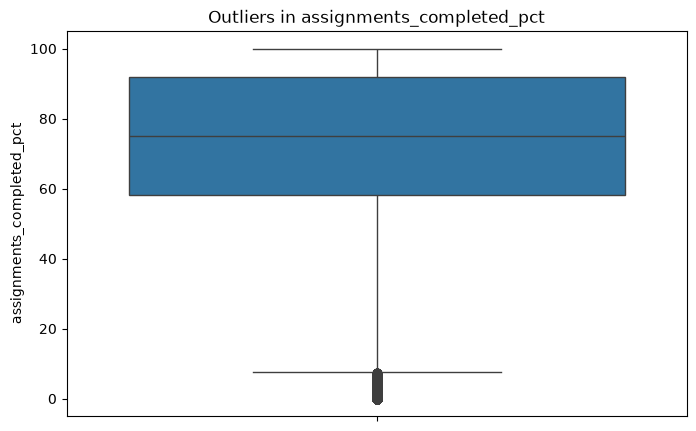

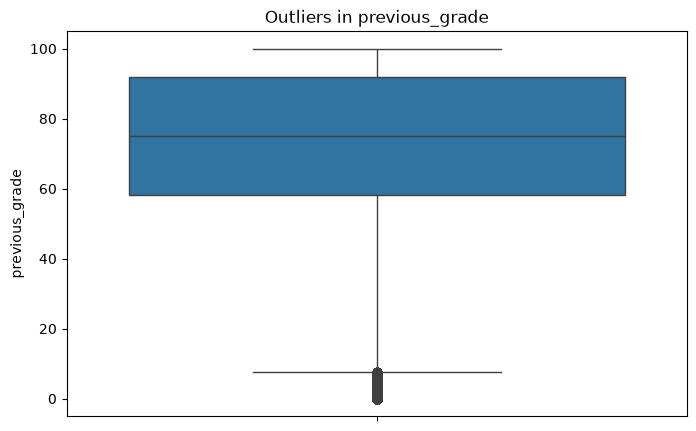

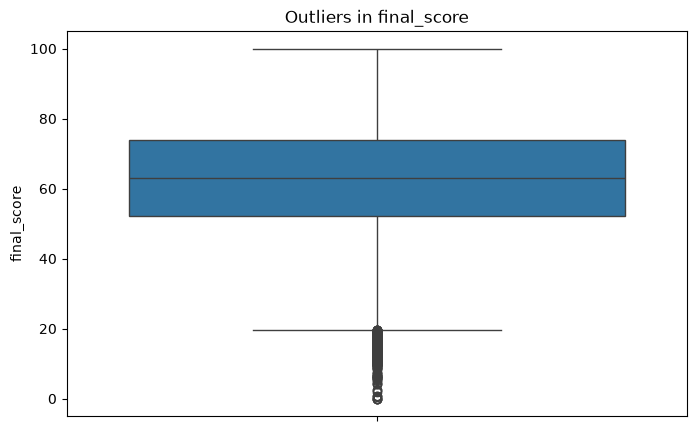

In [7]:
for col in outlier_cols:
    
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, y=col)

    plt.title(f'Outliers in {col}')
    plt.ylabel(col)

    plt.show()

In [8]:
df[outlier_cols] =df[outlier_cols].clip(lower=lower, upper=upper, axis=1)


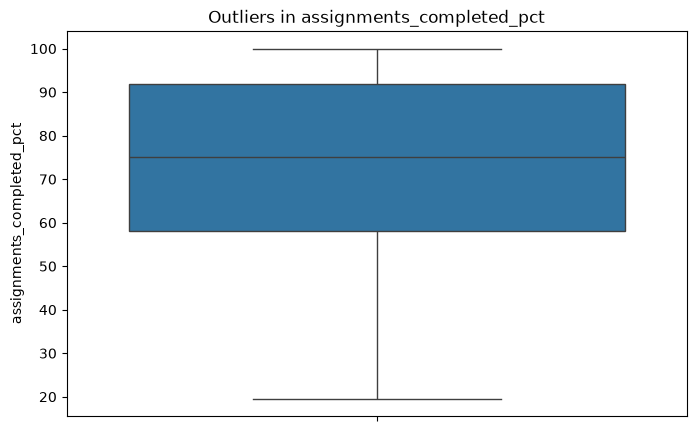

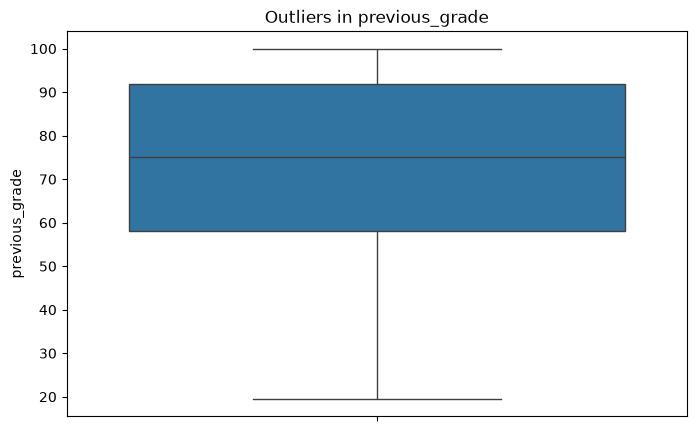

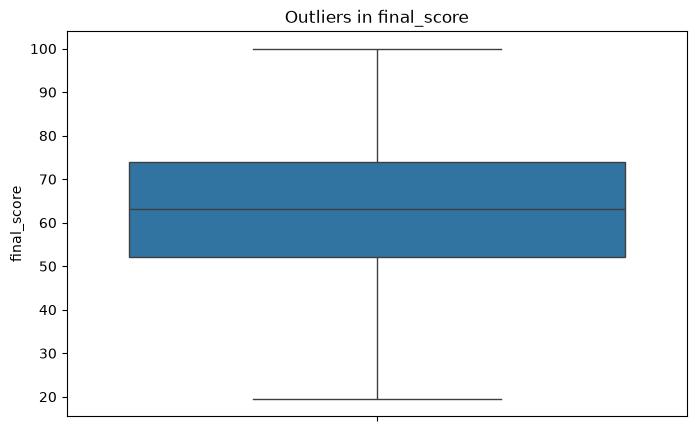

In [9]:
for col in outlier_cols:
    
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, y=col)

    plt.title(f'Outliers in {col}')
    plt.ylabel(col)

    plt.show()

In [10]:
x=df.drop('risk_category',axis=1)
y=df['risk_category']

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [12]:
x_train.isnull().sum()

attendance                   787
study_hours                  809
past_failures                  0
assignments_completed_pct      0
parental_education             0
family_income                  0
extracurricular                0
internet_access                0
previous_grade                 0
final_score                    0
dtype: int64

In [13]:
x_train.select_dtypes(include='number').columns

Index(['attendance', 'study_hours', 'past_failures',
       'assignments_completed_pct', 'previous_grade', 'final_score'],
      dtype='str')

In [14]:
from sklearn.impute import SimpleImputer

num_cols = x_train.select_dtypes(include="number").columns

imputer = SimpleImputer(strategy="median")
x_train[num_cols] = imputer.fit_transform(x_train[num_cols])

x_test[num_cols] = imputer.transform(x_test[num_cols])

In [15]:
x_train.select_dtypes(include='str').columns

Index(['parental_education', 'family_income', 'extracurricular',
       'internet_access'],
      dtype='str')

In [16]:
cat_cols = x_train.select_dtypes(include='str').columns

x_train = pd.get_dummies(x_train, columns=cat_cols)

x_test = pd.get_dummies(x_test, columns=cat_cols)

x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test=le.transform(y_test)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [19]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
y_pred=model.predict(x_test)

In [21]:
from sklearn.metrics import classification_report,confusion_matrix

print(f'classification_report : {classification_report(y_test,y_pred)}')
print(f'confusion_matrix : {confusion_matrix(y_test,y_pred)}')

classification_report :               precision    recall  f1-score   support

           0       0.93      0.94      0.94      9914
           1       0.95      0.93      0.94      5104
           2       0.94      0.93      0.93      4982

    accuracy                           0.94     20000
   macro avg       0.94      0.93      0.94     20000
weighted avg       0.94      0.94      0.94     20000

confusion_matrix : [[9345  256  313]
 [ 339 4762    3]
 [ 359    2 4621]]


In [22]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

rf_model.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [23]:
rf_preds = rf_model.predict(x_test)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print(f'classification_report : {classification_report(y_test,y_pred)}')
print(f'confusion_matrix : {confusion_matrix(y_test,y_pred)}')

classification_report :               precision    recall  f1-score   support

           0       0.93      0.94      0.94      9914
           1       0.95      0.93      0.94      5104
           2       0.94      0.93      0.93      4982

    accuracy                           0.94     20000
   macro avg       0.94      0.93      0.94     20000
weighted avg       0.94      0.94      0.94     20000

confusion_matrix : [[9345  256  313]
 [ 339 4762    3]
 [ 359    2 4621]]


In [25]:
import xgboost as xgb
model = xgb.XGBClassifier(
    n_estimators=100,      
    learning_rate=0.1,   
    max_depth=5,            
    random_state=42)

model.fit(x_train, y_train)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) 

In [26]:
y_pred = model.predict(x_test)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print(f'classification_report : {classification_report(y_test,y_pred)}')
print(f'confusion_matrix : {confusion_matrix(y_test,y_pred)}')

classification_report :               precision    recall  f1-score   support

           0       0.89      0.94      0.91      9914
           1       0.94      0.89      0.91      5104
           2       0.93      0.89      0.91      4982

    accuracy                           0.91     20000
   macro avg       0.92      0.90      0.91     20000
weighted avg       0.91      0.91      0.91     20000

confusion_matrix : [[9300  291  323]
 [ 573 4529    2]
 [ 558    2 4422]]
